# Classificação Binária de Dengue — MLP

Dataset: `../data/data_set_final.csv`  
Target: `CLASSI_FIN`  
Ambiente-alvo: Python 3.12.4 (Anaconda3)

## 1. Objetivo do notebook

Treinar e avaliar um modelo de classificação binária para prever `CLASSI_FIN` com split estratificado, apresentando métricas obrigatórias e validação final de execução.

## 2. Imports e configuração de ambiente

In [1]:
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

RANDOM_STATE = 42
TEST_SIZE = 0.2

np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid')

print('Python:', sys.version.split()[0])
print('Executável:', sys.executable)


Python: 3.12.4
Executável: /home/perazzojoao/anaconda3/envs/tf_gpu/bin/python


## 3. Carga dos dados

In [2]:
DATA_PATH = '../data/data_set_final.csv'
df = pd.read_csv(DATA_PATH)
print(f'Dataset carregado de: {DATA_PATH}')
print('Shape:', df.shape)


Dataset carregado de: ../data/data_set_final.csv
Shape: (11448, 27)


## 4. Checagens básicas

,NU_IDADE_N,CS_SEXO,CS_GESTANT,CS_RACA,CS_ZONA,FEBRE,MIALGIA,CEFALEIA,EXANTEMA,VOMITO,...,DOR_RETRO,DIABETES,HEMATOLOG,HEPATOPAT,RENAL,HIPERTENSA,ACIDO_PEPT,AUTO_IMUNE,DIAS,CLASSI_FIN
0,4003.0,1,6.0,9.0,9.0,1.0,1.0,2.0,1.0,1.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,5,1
1,4043.0,0,9.0,9.0,1.0,1.0,1.0,2.0,1.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,19,1
2,4039.0,0,5.0,4.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,7,1
3,4008.0,1,6.0,9.0,9.0,1.0,2.0,1.0,1.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,3,1
4,4014.0,1,6.0,9.0,9.0,1.0,1.0,1.0,1.0,1.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,0,1



Tipos de dados:


,qtd
float64,24
int64,3



Nulos por coluna (top 10):


,nulos
NU_IDADE_N,0
CS_SEXO,0
CS_GESTANT,0
CS_RACA,0
CS_ZONA,0
FEBRE,0
MIALGIA,0
CEFALEIA,0
EXANTEMA,0
VOMITO,0



Distribuição da classe CLASSI_FIN:
CLASSI_FIN
0    5724
1    5724
Name: count, dtype: int64


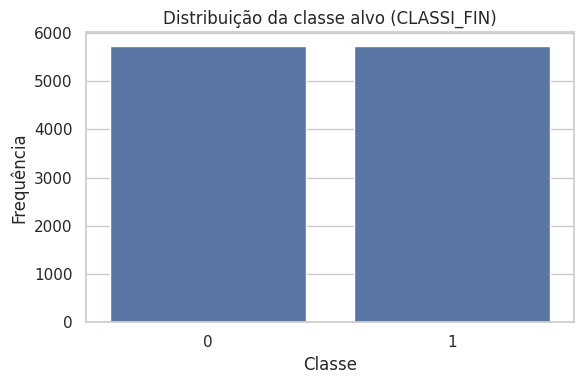

In [3]:
display(df.head())
print('\nTipos de dados:')
display(df.dtypes.value_counts().to_frame('qtd'))
print('\nNulos por coluna (top 10):')
display(df.isnull().sum().sort_values(ascending=False).head(10).to_frame('nulos'))
print('\nDistribuição da classe CLASSI_FIN:')
class_dist = df['CLASSI_FIN'].value_counts().sort_index()
print(class_dist)

plt.figure(figsize=(6,4))
sns.countplot(x='CLASSI_FIN', data=df)
plt.title('Distribuição da classe alvo (CLASSI_FIN)')
plt.xlabel('Classe')
plt.ylabel('Frequência')
plt.tight_layout()
plt.show()


## 5. Separação X/y e split estratificado treino/teste

In [4]:
TARGET = 'CLASSI_FIN'
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print('X_train:', X_train.shape, '| X_test:', X_test.shape)
print('Distribuição y_train:')
print(y_train.value_counts(normalize=True).sort_index())
print('Distribuição y_test:')
print(y_test.value_counts(normalize=True).sort_index())


X_train: (9158, 26) | X_test: (2290, 26)
Distribuição y_train:
CLASSI_FIN
0    0.5
1    0.5
Name: proportion, dtype: float64
Distribuição y_test:
CLASSI_FIN
0    0.5
1    0.5
Name: proportion, dtype: float64


## 6. Pipeline/preparo específico do modelo

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

# Sem vazamento: scaler ajustado apenas no treino e aplicado no teste.
scaler = StandardScaler()
X_train_prepared = scaler.fit_transform(X_train)
X_test_prepared = scaler.transform(X_test)

model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    alpha=1e-4,
    learning_rate_init=1e-3,
    max_iter=400,
    random_state=RANDOM_STATE,
)


## 7. Treinamento do modelo

In [6]:
model.fit(X_train_prepared, y_train)
print('Treinamento MLP concluído.')


Treinamento MLP concluído.


## 8. Avaliação obrigatória

Classification Report:

              precision    recall  f1-score   support

           0     0.6716    0.6393    0.6550      1145
           1     0.6558    0.6873    0.6712      1145

    accuracy                         0.6633      2290
   macro avg     0.6637    0.6633    0.6631      2290
weighted avg     0.6637    0.6633    0.6631      2290



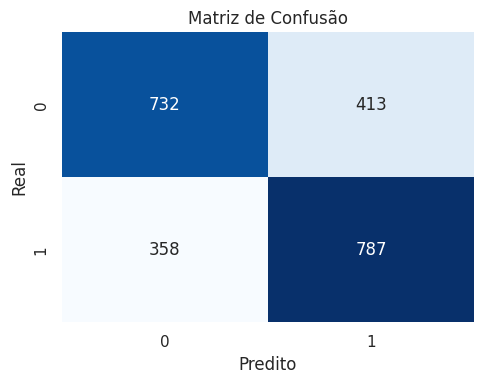

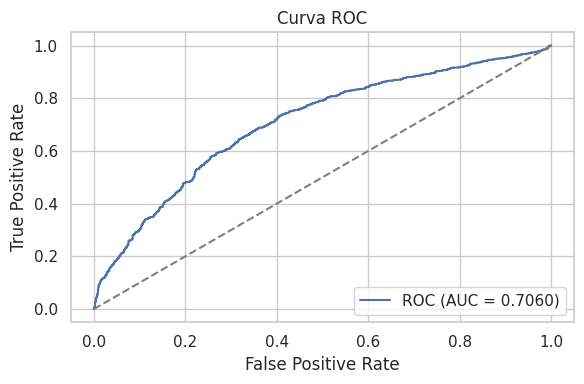

In [7]:
y_pred = model.predict(X_test_prepared)
y_score = model.predict_proba(X_test_prepared)[:, 1]

report_text = classification_report(y_test, y_pred, digits=4)
print('Classification Report:\n')
print(report_text)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusão')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_score)
auc_value = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'ROC (AUC = {auc_value:.4f})')
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


## 9. Resumo de métricas do notebook

In [8]:
metrics_summary = {
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred, zero_division=0),
    'recall': recall_score(y_test, y_pred, zero_division=0),
    'f1': f1_score(y_test, y_pred, zero_division=0),
    'auc': auc_value,
}

metrics_df = pd.DataFrame([metrics_summary]).round(4)
display(metrics_df)


,accuracy,precision,recall,f1,auc
0,0.6633,0.6558,0.6873,0.6712,0.706


## 10. Conclusões do modelo

- O MLP foi treinado com `StandardScaler` aplicado sem vazamento de dados.
- A rede neural pode capturar relações complexas, porém é mais sensível à escala e configuração.

## Validação Final

In [9]:
checks = {
    'classification_report': isinstance(report_text, str) and len(report_text) > 0,
    'matriz_confusao': cm.shape == (2, 2),
    'auc_roc': 0.0 <= auc_value <= 1.0,
}

status = 'APROVADO' if all(checks.values()) else 'REPROVADO'

print('Status da validação final:', status)
print('Métricas obrigatórias presentes:', checks)
print('Execução completa sem erro: SIM (célula final alcançada)')
print('Versão do Python:', sys.version.split()[0])
print('Distribuição esperada: Anaconda3')

assert all(checks.values()), 'Falha na validação das métricas obrigatórias.'


Status da validação final: APROVADO
Métricas obrigatórias presentes: {'classification_report': True, 'matriz_confusao': True, 'auc_roc': True}
Execução completa sem erro: SIM (célula final alcançada)
Versão do Python: 3.12.4
Distribuição esperada: Anaconda3
